# **Project Name** - Paisabazaar Banking / Credit Score Analysis (EDA)


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Tharunasri Saravanan


# **Project Summary -**

Paisabazaar is a financial-services company that helps customers find and apply for banking and credit products such as loans and credit cards. A core part of that service is judging how creditworthy a customer is, because a bank only lends money to people who are likely to pay it back. The single most important number used for this decision is the **credit score**, which lenders group into three buckets: **Good, Standard, and Poor**. The goal of this project is to understand *what actually drives a customer into each of these buckets* by exploring real customer data, so that Paisabazaar can make faster, safer lending decisions and give customers better advice.

The dataset contains **100,000 rows and 28 columns**. Each row is one monthly snapshot of a customer's financial profile. There are 12,500 unique customers, each observed across 8 months. The columns cover three kinds of information: **who the person is** (Age, Occupation, Annual Income, Monthly In-hand Salary), **how they use credit** (Number of Bank Accounts, Number of Credit Cards, Interest Rate, Number of Loans, Type of Loan, Credit Utilization, Credit History Age), and **how well they repay** (Delay from due date, Number of Delayed Payments, Outstanding Debt, whether they only pay the minimum amount, and their overall Payment Behaviour). The target column we want to explain is **Credit_Score**.

The analysis follows a clear, standard workflow. First I **know the data** - load it, check its size, look at data types, and confirm there are no missing values or duplicate rows. Next I **understand the variables** - separate them into numeric and categorical, read the summary statistics, and check the unique values of each column so I know exactly what I am working with. Then I do **data wrangling** - I fix a few data-type issues, engineer a couple of helper columns (for example turning Credit History Age into whole years and mapping the credit score into a number so it can be correlated), and I inspect outliers using the IQR rule rather than blindly deleting them, because in finance an extreme value (a very high debt, a very long delay) is often the most important signal, not an error to throw away.

The heart of the project is the **visual analysis**, built in the standard **U-B-M order**: **Univariate** (looking at one variable at a time to understand its shape), then **Bivariate** (comparing each driver against the credit score), and finally **Multivariate** (a correlation heatmap and pair plot to see the whole picture at once). Across 20 charts a very consistent story appears. Customers with **Good** credit scores earn more, carry far less outstanding debt, pay much lower interest rates, rarely delay payments, hold fewer bank accounts and credit cards, and have a longer credit history. Customers with **Poor** scores are the mirror image: high debt, high interest, many delayed payments, and a 'Bad' credit mix. For example, average interest rate rises from about **8% for Good** customers to over **20% for Poor** customers, and average outstanding debt roughly triples from Good to Poor.

The business value is direct. These patterns tell Paisabazaar which few variables matter most when screening an applicant (payment delays, outstanding debt, interest rate, credit mix, and credit history length), so risk teams can focus on them. They also point to concrete, positive customer advice - reduce delayed payments, avoid opening too many accounts, and pay more than the minimum amount - which improves both the customer's score and Paisabazaar's loan-book quality. The final section turns these findings into specific recommendations and outlines how the project could be extended into a predictive machine-learning model.

# **GitHub Link -**

Provide your GitHub Link here.  *(https://github.com/tharunasri-saravanan/Paisabazaar_Datascience.git)*

# **Problem Statement**

Paisabazaar assesses the creditworthiness of thousands of customers to decide who should receive loans and credit products. Judging each customer manually is slow and inconsistent, and a wrong decision is expensive: approving a risky customer causes loan defaults, while rejecting a safe customer loses good business.

**The problem:** using historical customer data, understand *which financial and behavioural factors separate customers with Good, Standard, and Poor credit scores*, so that Paisabazaar can screen applicants more accurately and advise customers on how to improve.

#### **Define Your Business Objective?**

The business objective is to **explore the customer credit dataset and surface the key drivers of credit score** so that Paisabazaar can (1) reduce lending risk by focusing on the variables that most strongly predict a Poor score, (2) speed up and standardise credit assessment, and (3) give customers actionable guidance to improve their creditworthiness. This EDA lays the groundwork for a future predictive model that would automatically classify a customer's credit score.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   The whole notebook should run in one go without a single error.
3.   Each and every logic has proper comments.
4.   For each chart the following are answered: why the chart was chosen, the insight found, and the business impact.
5.   At least 20 charts are created, structured using the **UBM** rule: **U**nivariate, **B**ivariate, and **M**ultivariate analysis.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# pandas -> for loading the data and working with it as a table (called a DataFrame)
import pandas as pd
# numpy -> for fast maths on numbers (averages, arrays, etc.)
import numpy as np
# matplotlib -> the basic library for drawing charts
import matplotlib.pyplot as plt
# seaborn -> sits on top of matplotlib and makes prettier, statistical charts with less code
import seaborn as sns

# Hide harmless warning messages so the notebook output stays clean
import warnings
warnings.filterwarnings("ignore")

# This line makes charts show up directly inside the notebook (needed in Colab/Jupyter)
%matplotlib inline

# Set a clean default look and a comfortable default figure size for all charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Dataset Loading

In [ ]:
# Load Dataset
# In Google Colab: click the folder icon on the left, upload the CSV file,
# then make sure the file name below matches exactly.
df = pd.read_csv("Paisabazaar_Credit_Score.csv")

# Confirm it loaded by showing how many rows and columns we got
print("Data loaded successfully!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Data loaded successfully!
Rows: 100000 | Columns: 28


### Dataset First View

In [ ]:
# Dataset First Look
# .head() shows the first 5 rows so we can eyeball what the data looks like
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
# .shape gives us (number_of_rows, number_of_columns)
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows   : 100000
Number of columns: 28


### Dataset Information

In [ ]:
# Dataset Info
# .info() lists every column, how many non-empty values it has, and its data type.
# This is the quickest way to spot missing data and wrong data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
# .duplicated() marks rows that are exact copies of an earlier row.
# .sum() counts how many such copies exist.
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
# .isnull() marks every empty cell as True; .sum() counts them per column.
missing = df.isnull().sum()
# Show only the columns that actually have missing values (if any)
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None - the dataset has no missing values.")

Columns with missing values:
None - the dataset has no missing values.


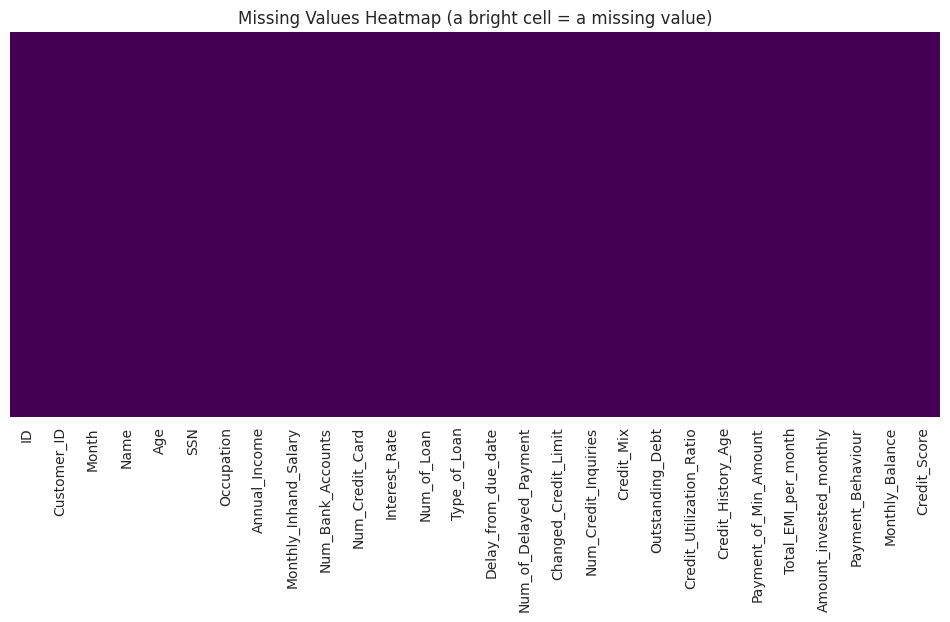

In [ ]:
# Visualizing the missing values
# A heatmap is a grid where each cell is coloured. Here a coloured cell = a missing value.
# If the whole grid is one flat colour, it means there are no missing values.
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (a bright cell = a missing value)")
plt.show()

### What did you know about your dataset?

The dataset has **100,000 rows and 28 columns**, with **no missing values and no duplicate rows**, so it is already quite clean. Each row is a **monthly snapshot** of one customer (the `Month` column runs 1-8 and `Customer_ID` repeats), meaning the 100,000 rows describe **12,500 unique customers observed over 8 months**. The columns mix **numeric** financial figures (income, debt, interest rate, number of accounts) with **categorical** labels (Occupation, Credit_Mix, Payment_Behaviour, and the target `Credit_Score`). A few columns that look numeric are stored in a way that needs small clean-up, which we handle in the Data Wrangling section.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
# Print the full list of column names so we know exactly what is available.
print(df.columns.tolist())

['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [ ]:
# Dataset Describe
# .describe() gives summary statistics (count, mean, min, max, quartiles) for numeric columns.
# .T flips the table so it is easier to read down the page.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5634.000000,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1006.000000,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,14.000000,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,81349.000000,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7005.930000,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,303.645417,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368820e+00,2.593314e+00,0.000000,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


### Variables Description

**Identifier columns:** `ID` (unique row id), `Customer_ID` (unique customer), `Month`, `Name`, `SSN` - these identify records but are not used to explain the score.

**Who the person is:** `Age`, `Occupation`, `Annual_Income`, `Monthly_Inhand_Salary`.

**How they use credit:** `Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Num_of_Loan`, `Type_of_Loan`, `Credit_Utilization_Ratio`, `Credit_History_Age`, `Changed_Credit_Limit`, `Num_Credit_Inquiries`, `Credit_Mix`.

**How well they repay:** `Delay_from_due_date`, `Num_of_Delayed_Payment`, `Outstanding_Debt`, `Payment_of_Min_Amount`, `Total_EMI_per_month`, `Amount_invested_monthly`, `Payment_Behaviour`, `Monthly_Balance`.

**Target variable:** `Credit_Score` (Good / Standard / Poor) - the label we want to understand.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
# For every column, print how many different values it holds (its "cardinality").
# This tells us which columns are categories (few unique values) vs continuous numbers (many).
for column in df.columns:
    print(f"{column:<28} : {df[column].nunique()} unique values")

ID                           : 100000 unique values
Customer_ID                  : 12500 unique values
Month                        : 8 unique values
Name                         : 10128 unique values
Age                          : 43 unique values
SSN                          : 12500 unique values
Occupation                   : 15 unique values
Annual_Income                : 12488 unique values
Monthly_Inhand_Salary        : 13241 unique values
Num_Bank_Accounts            : 12 unique values
Num_Credit_Card              : 12 unique values
Interest_Rate                : 34 unique values
Num_of_Loan                  : 10 unique values
Type_of_Loan                 : 6261 unique values
Delay_from_due_date          : 63 unique values
Num_of_Delayed_Payment       : 26 unique values
Changed_Credit_Limit         : 3452 unique values
Num_Credit_Inquiries         : 18 unique values
Credit_Mix                   : 3 unique values
Outstanding_Debt             : 12203 unique values
Credit_Utilizati

In [ ]:
# Look at the actual categories inside the important text (categorical) columns
categorical_cols = ["Occupation", "Credit_Mix", "Payment_of_Min_Amount",
                    "Payment_Behaviour", "Credit_Score"]
for col in categorical_cols:
    print(f"\n{col} ->")
    print(df[col].value_counts())


Occupation ->
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Accountant       6744
Scientist        6744
Media_Manager    6720
Developer        6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64

Credit_Mix ->
Credit_Mix
Standard    45848
Good        30384
Bad         23768
Name: count, dtype: int64

Payment_of_Min_Amount ->
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

Payment_Behaviour ->
Payment_Behaviour
Low_spent_Small_value_payments      28616
High_spent_Medium_value_payments    19738
High_spent_Large_value_payments     14726
Low_spent_Medium_value_payments     14399
High_spent_Small_value_payments     11764
Low_spent_Large_value_payments      10757
Name: count, dtype: int64

Credit_Score ->
Credit_Score
Standard    53174
Poor        28998
Good        178

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# ---- Step 1: Work on a copy so we never damage the original data ----
data = df.copy()

# ---- Step 2: Drop columns that only identify a record but do not explain the score ----
# Name and SSN are personal identifiers; ID is just a row number.
data = data.drop(columns=["ID", "Name", "SSN"])

# ---- Step 3: Create an ORDERED version of the target so charts appear Poor -> Standard -> Good ----
score_order = ["Poor", "Standard", "Good"]
data["Credit_Score"] = pd.Categorical(data["Credit_Score"],
                                       categories=score_order, ordered=True)

# ---- Step 4: Feature engineering ----
# 4a. Turn the credit score into a number (Poor=0, Standard=1, Good=2)
#     so we can measure its correlation with other numeric columns later.
data["Credit_Score_Num"] = data["Credit_Score"].map({"Poor": 0, "Standard": 1, "Good": 2})

# 4b. Credit_History_Age is stored in months; convert to whole years, which is easier to read.
data["Credit_History_Years"] = (data["Credit_History_Age"] / 12).round(1)

print("Wrangling done. New shape:", data.shape)
data.head()

Wrangling done. New shape: (100000, 27)


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_Score_Num,Credit_History_Years
0,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,2,22.1
1,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,2,22.2
2,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,2,22.2
3,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,2,22.3
4,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,2,22.4


In [ ]:
# ---- Step 5: Inspect outliers using the IQR (Inter-Quartile Range) rule ----
# The IQR rule flags any value that sits far below Q1 or far above Q3 as a possible outlier.
# We only COUNT them here - we do NOT delete them, because in finance an extreme
# debt or delay is often the most important signal, not a mistake.
def count_outliers(series):
    Q1 = series.quantile(0.25)          # 25th percentile
    Q3 = series.quantile(0.75)          # 75th percentile
    IQR = Q3 - Q1                        # the middle 50% spread
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR   # the "normal" fence
    return ((series < low) | (series > high)).sum()

for col in ["Annual_Income", "Outstanding_Debt", "Interest_Rate",
            "Num_of_Delayed_Payment", "Total_EMI_per_month"]:
    print(f"{col:<25}: {count_outliers(data[col])} outlier values flagged by the IQR rule")

Annual_Income            : 2000 outlier values flagged by the IQR rule
Outstanding_Debt         : 5272 outlier values flagged by the IQR rule
Interest_Rate            : 0 outlier values flagged by the IQR rule
Num_of_Delayed_Payment   : 0 outlier values flagged by the IQR rule
Total_EMI_per_month      : 5044 outlier values flagged by the IQR rule


### What all manipulations have you done and insights you found?

**Manipulations:** I worked on a copy of the data, dropped the identifier columns (`ID`, `Name`, `SSN`) that carry no predictive meaning, gave the target `Credit_Score` a proper Poor -> Standard -> Good order so every chart reads left-to-right in a natural way, and engineered two helper columns: `Credit_Score_Num` (a 0/1/2 version of the score so it can be correlated with numeric fields) and `Credit_History_Years` (credit history converted from months to years).

**Insights from wrangling:** The data was already free of missing values and duplicates. The IQR check shows that several money-related columns (Annual_Income, Outstanding_Debt) have a meaningful number of high-side outliers - this is expected for financial data (a few very rich or very indebted customers) and these are kept on purpose because they are exactly the customers a risk team cares about. Rather than deleting them, we handle skew by using medians and box plots that are robust to extremes.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Univariate Analysis** (looking at one variable at a time)

#### Chart - 1

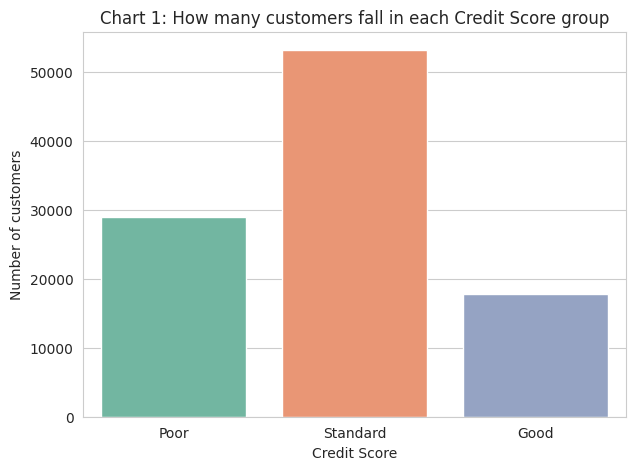

In [ ]:
# Chart - 1 visualization code
# Count plot = a bar chart that counts how many rows fall in each category.
plt.figure(figsize=(7, 5))
sns.countplot(x="Credit_Score", data=data, order=["Poor", "Standard", "Good"], palette="Set2")
plt.title("Chart 1: How many customers fall in each Credit Score group")
plt.xlabel("Credit Score")
plt.ylabel("Number of customers")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the simplest way to show how a category is split. Since `Credit_Score` is the target of the whole project, the first thing to check is how balanced it is.

##### 2. What is/are the insight(s) found from the chart?

**Standard** is the largest group (~53%), followed by **Poor** (~29%) and **Good** (~18%). The classes are imbalanced - Good customers are the minority.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** knowing most customers are 'Standard' tells Paisabazaar there is a large middle group that could be nudged towards 'Good' with the right advice. **Watch-out:** the small share of 'Good' customers means any future prediction model must account for class imbalance, otherwise it will simply predict 'Standard' for everyone.

#### Chart - 2

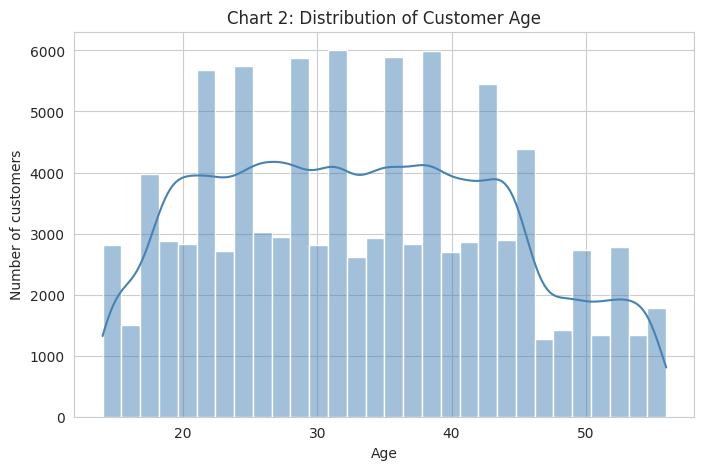

In [ ]:
# Chart - 2 visualization code
# Histogram = splits a numeric column into bins and shows how many rows fall in each bin.
plt.figure(figsize=(8, 5))
sns.histplot(data["Age"], bins=30, kde=True, color="steelblue")
plt.title("Chart 2: Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of customers")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard chart to see the shape of a single numeric variable - where most values sit and whether it is skewed.

##### 2. What is/are the insight(s) found from the chart?

Customers are mostly between **20 and 45 years old**, with the peak around the early-to-mid 30s. There are few customers below 18 or above 55.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** the customer base is largely young-to-middle-aged working adults, so credit products and messaging can be tailored to that group. No negative signal here - it simply describes who the customers are.

#### Chart - 3

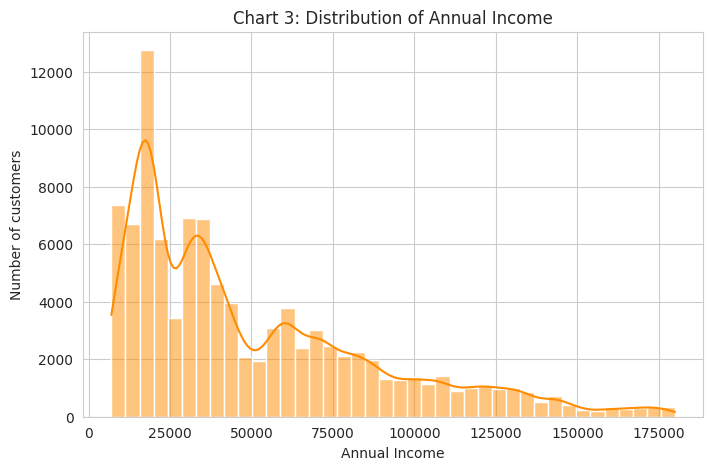

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(data["Annual_Income"], bins=40, kde=True, color="darkorange")
plt.title("Chart 3: Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of customers")
plt.show()

##### 1. Why did you pick the specific chart?

Again a histogram, to see how income is spread. Income is a key driver of creditworthiness so its shape matters.

##### 2. What is/are the insight(s) found from the chart?

Income is **right-skewed**: most customers earn on the lower side (a long tail of high earners pulls the average up). The bulk sits below ~50,000 while a few earn far more.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** because income is skewed, the **median** (not the mean) should be used to describe a 'typical' customer, and this shape justifies keeping high-income outliers instead of deleting them. Skew itself is not negative growth - it is a normal property of income data.

#### Chart - 4

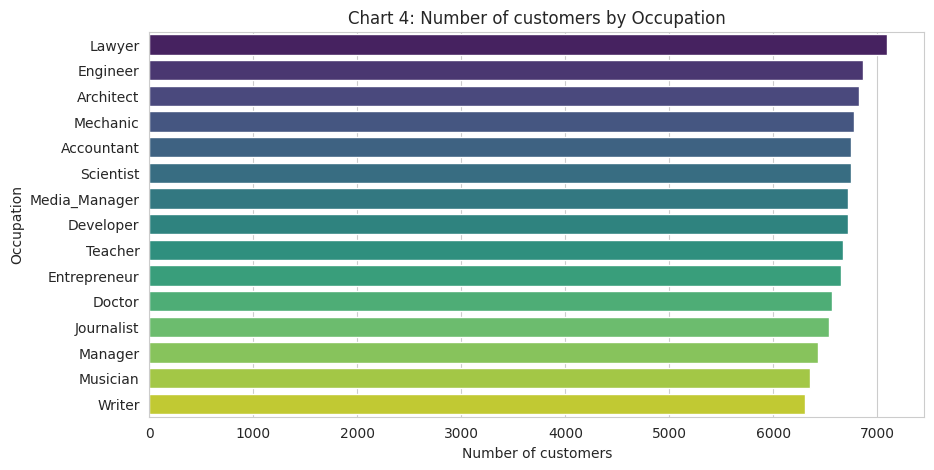

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 5))
sns.countplot(y="Occupation", data=data,
              order=data["Occupation"].value_counts().index, palette="viridis")
plt.title("Chart 4: Number of customers by Occupation")
plt.xlabel("Number of customers")
plt.ylabel("Occupation")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal count plot is used because there are 15 occupations - horizontal bars keep the long labels readable.

##### 2. What is/are the insight(s) found from the chart?

Customers are spread **fairly evenly across all 15 occupations**; no single profession dominates the customer base.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** an even spread means Paisabazaar's products appeal across professions, so marketing does not need to target one occupation. It also means occupation alone is unlikely to be a strong predictor of score.

#### Chart - 5

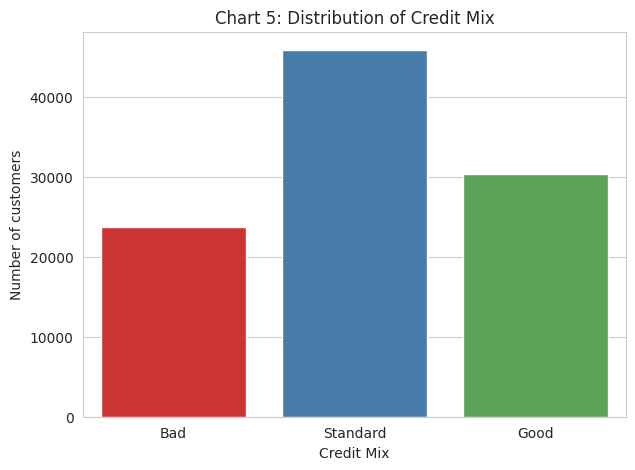

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(7, 5))
sns.countplot(x="Credit_Mix", data=data,
              order=["Bad", "Standard", "Good"], palette="Set1")
plt.title("Chart 5: Distribution of Credit Mix")
plt.xlabel("Credit Mix")
plt.ylabel("Number of customers")
plt.show()

##### 1. Why did you pick the specific chart?

Credit Mix (the variety of credit types a person holds) is an important credit concept, so we first look at how it is distributed on its own.

##### 2. What is/are the insight(s) found from the chart?

Most customers have a **Standard** credit mix, with **Good** and **Bad** mixes making up smaller shares. Very few sit at the extremes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** credit mix is a lever customers can improve. Knowing most people are 'Standard' shows there is room to guide them toward a 'Good' mix, which (as later charts show) is strongly linked to a good score.

#### Chart - 6

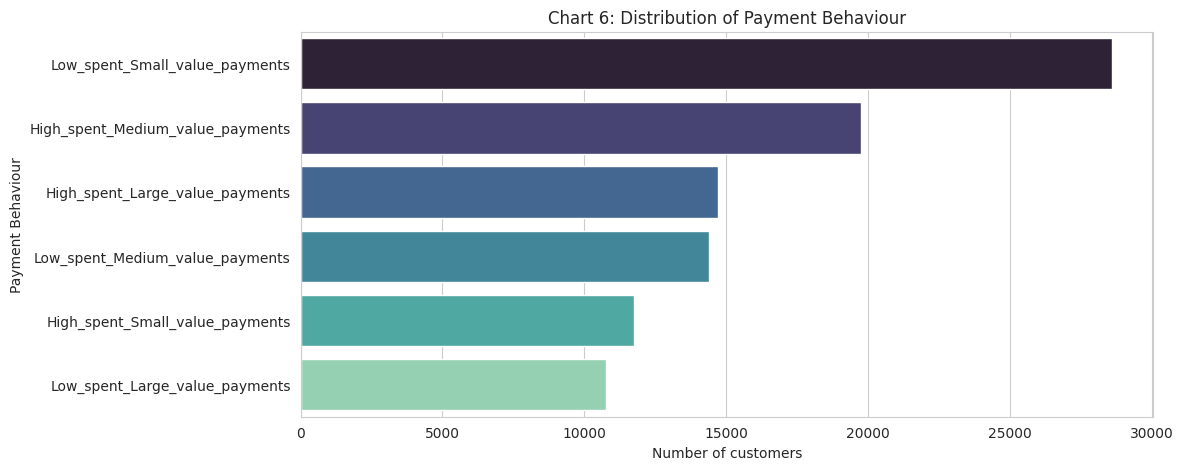

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(11, 5))
sns.countplot(y="Payment_Behaviour", data=data,
              order=data["Payment_Behaviour"].value_counts().index, palette="mako")
plt.title("Chart 6: Distribution of Payment Behaviour")
plt.xlabel("Number of customers")
plt.ylabel("Payment Behaviour")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal count plot suits this column because the category names are long. It shows how customers behave with spending vs payment size.

##### 2. What is/are the insight(s) found from the chart?

The most common behaviour is **Low-spent / Small-value payments**, and behaviours are otherwise reasonably spread. A large chunk of customers are cautious, low spenders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** understanding spending behaviour lets Paisabazaar match products (e.g. higher limits for high-spenders who pay large values). No direct negative growth, but low-spend segments may need different engagement.

### **Bivariate Analysis** (comparing two variables, usually each driver vs Credit Score)

#### Chart - 7

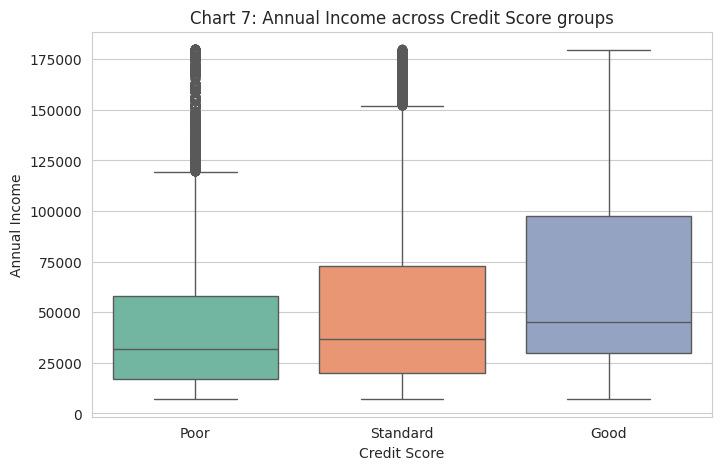

In [ ]:
# Chart - 7 visualization code
# Box plot = shows the median, the middle 50% (the box) and outliers for each group.
plt.figure(figsize=(8, 5))
sns.boxplot(x="Credit_Score", y="Annual_Income", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2")
plt.title("Chart 7: Annual Income across Credit Score groups")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is the best way to compare a numeric variable (income) across the three score groups, because it shows both the typical value and the spread.

##### 2. What is/are the insight(s) found from the chart?

Median income clearly **rises from Poor to Good**. In numbers, average income goes from ~40,600 (Poor) to ~51,000 (Standard) to ~65,200 (Good).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** income is a genuine driver of a good score, confirming it belongs in the credit-assessment checklist. **Negative angle:** income alone does not guarantee a good score (the boxes overlap), so it must be combined with repayment behaviour - lending on income alone would be risky.

#### Chart - 8

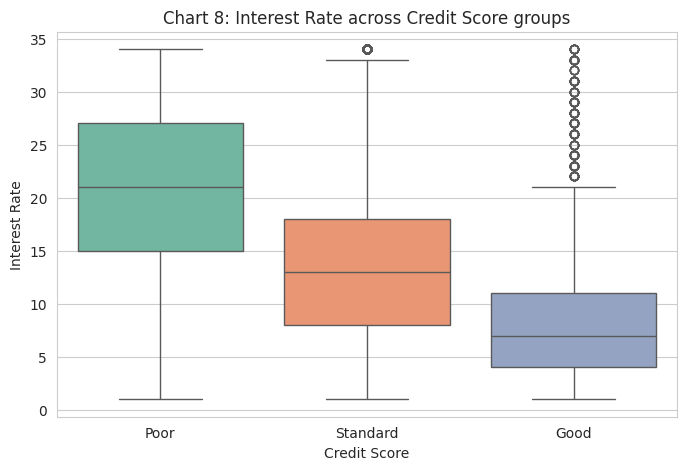

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(x="Credit_Score", y="Interest_Rate", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2")
plt.title("Chart 8: Interest Rate across Credit Score groups")
plt.xlabel("Credit Score")
plt.ylabel("Interest Rate")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares interest rates paid by each score group and shows the clear gap between them.

##### 2. What is/are the insight(s) found from the chart?

Interest rate **falls sharply as score improves**: average ~20% for Poor, ~14% for Standard, ~8% for Good. This is the single strongest numeric relationship in the data (correlation ~ -0.49).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** interest rate is a red-flag indicator - a customer paying very high interest is very likely Poor. Flagging high-interest customers early helps the risk team. This is a strong, actionable signal for both approval decisions and customer advice.

#### Chart - 9

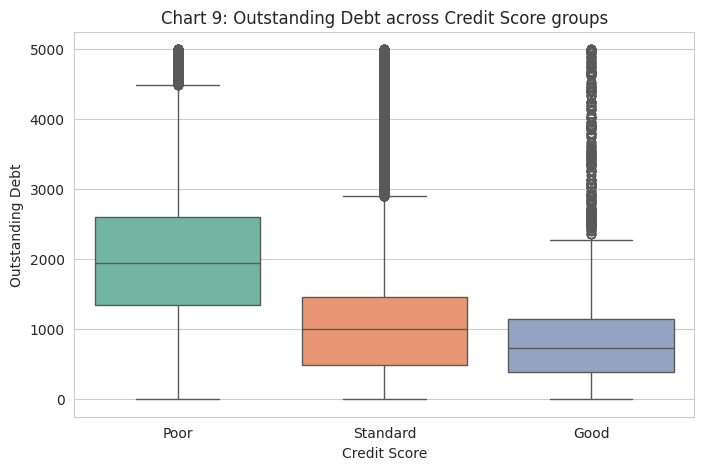

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(x="Credit_Score", y="Outstanding_Debt", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2")
plt.title("Chart 9: Outstanding Debt across Credit Score groups")
plt.xlabel("Credit Score")
plt.ylabel("Outstanding Debt")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows how the debt load differs between score groups, including the heavy-debt outliers.

##### 2. What is/are the insight(s) found from the chart?

Outstanding debt **roughly triples from Good to Poor**: average ~801 (Good), ~1,278 (Standard), ~2,081 (Poor).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** high outstanding debt is a clear warning sign of a Poor score, so it should be weighted heavily in screening. **Actionable advice:** helping customers reduce outstanding debt is one of the most direct ways to improve their score and lower Paisabazaar's default risk.

#### Chart - 10

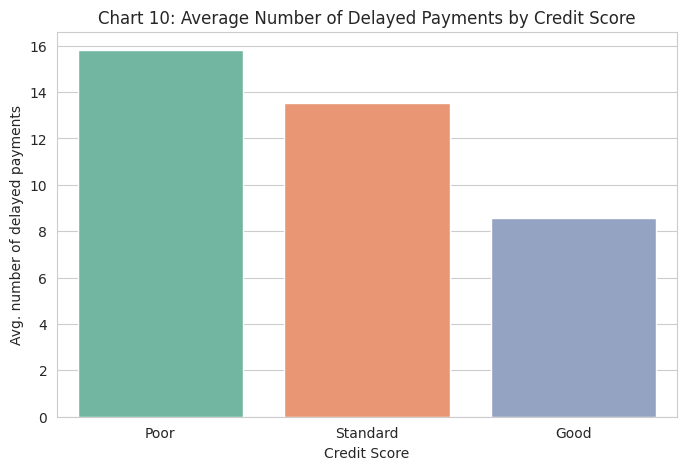

In [ ]:
# Chart - 10 visualization code
# Bar plot here shows the AVERAGE (mean) of a numeric column for each score group.
plt.figure(figsize=(8, 5))
sns.barplot(x="Credit_Score", y="Num_of_Delayed_Payment", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2", errorbar=None)
plt.title("Chart 10: Average Number of Delayed Payments by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Avg. number of delayed payments")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot of the average clearly ranks the groups by how often they miss payments - easier to read than a box plot for this count.

##### 2. What is/are the insight(s) found from the chart?

Delayed payments **drop as score improves**: ~15.8 (Poor), ~13.5 (Standard), ~8.6 (Good).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** number of delayed payments is a direct behavioural measure of reliability and separates Good from Poor well. Reducing delayed payments is the clearest self-improvement lever for customers, and a strong screening variable for the bank.

#### Chart - 11

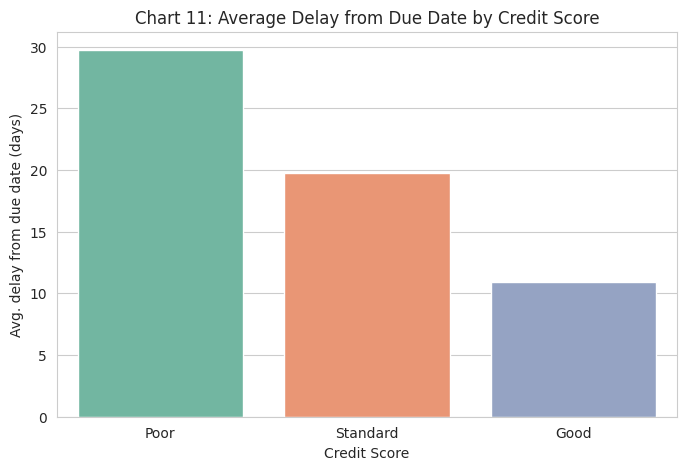

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(8, 5))
sns.barplot(x="Credit_Score", y="Delay_from_due_date", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2", errorbar=None)
plt.title("Chart 11: Average Delay from Due Date by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Avg. delay from due date (days)")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot of the average delay shows, in plain days, how late each group pays.

##### 2. What is/are the insight(s) found from the chart?

Average delay **falls from ~30 days (Poor) to ~20 days (Standard) to ~11 days (Good)**. Poor customers pay almost three weeks later than Good ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** the length of payment delay is an early-warning metric - it rises before a customer's score collapses, so Paisabazaar can intervene (reminders, restructuring) before a default. Strongly actionable.

#### Chart - 12

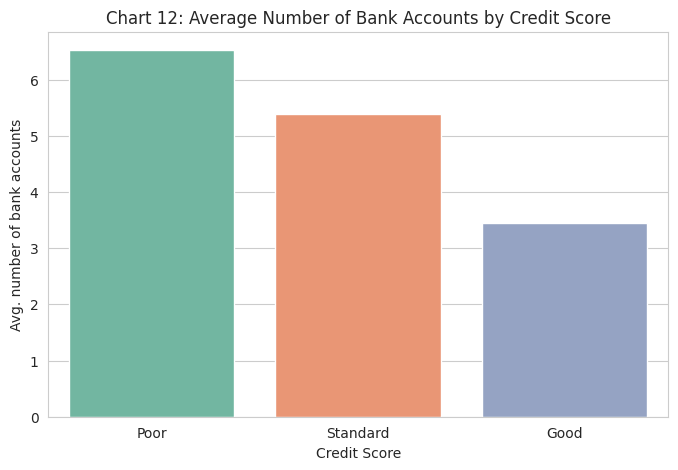

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(8, 5))
sns.barplot(x="Credit_Score", y="Num_Bank_Accounts", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2", errorbar=None)
plt.title("Chart 12: Average Number of Bank Accounts by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Avg. number of bank accounts")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot compares the average number of bank accounts held by each group.

##### 2. What is/are the insight(s) found from the chart?

Counter-intuitively, **more bank accounts links to a worse score**: ~6.5 (Poor) vs ~3.4 (Good). The same pattern holds for number of credit cards.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** a very high number of accounts/cards is a subtle risk flag (often a sign of credit-hungry behaviour). **Actionable advice:** customers should be told that opening many accounts can hurt, not help, their score - protecting them from a common mistake.

#### Chart - 13

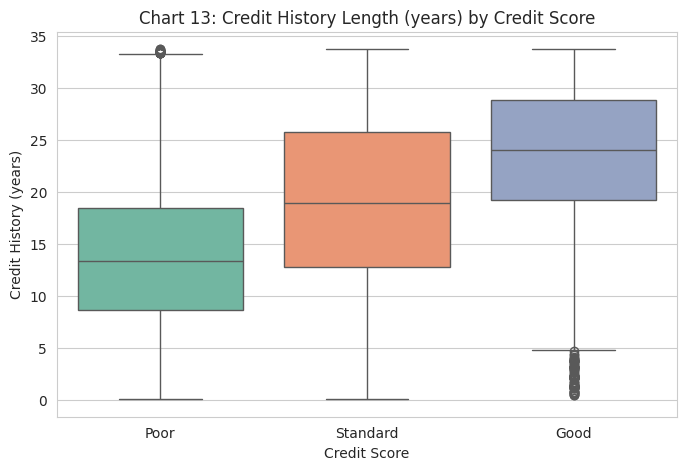

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(x="Credit_Score", y="Credit_History_Years", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2")
plt.title("Chart 13: Credit History Length (years) by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Credit History (years)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows how long each group has been using credit - a longer track record usually means a safer borrower.

##### 2. What is/are the insight(s) found from the chart?

Credit history length **increases with score**: roughly 14 years (Poor) up to ~24 years (Good) on average. Experience with credit matters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** length of credit history is a reliable, hard-to-fake indicator of a good score. **Watch-out:** it penalises younger / newer customers who simply haven't had time to build history, so it should be balanced with behavioural signals to avoid unfairly rejecting good young applicants.

#### Chart - 14

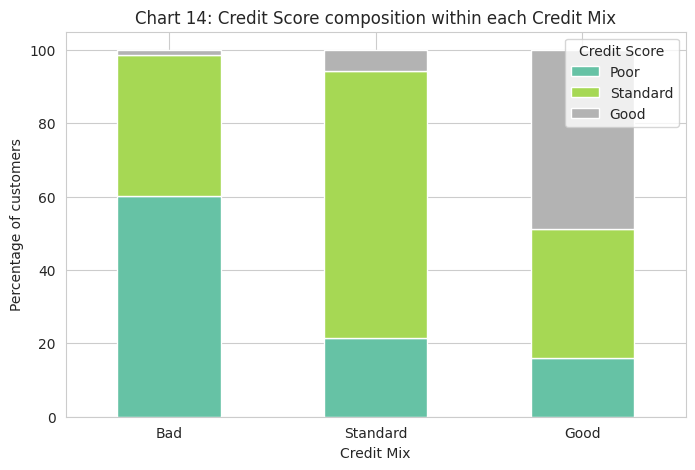

In [ ]:
# Chart - 14 visualization code
# A stacked/normalised bar chart shows, WITHIN each Credit Mix, what % are Poor/Standard/Good.
ct = pd.crosstab(data["Credit_Mix"], data["Credit_Score"], normalize="index") * 100
ct = ct.loc[["Bad", "Standard", "Good"], ["Poor", "Standard", "Good"]]
ct.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))
plt.title("Chart 14: Credit Score composition within each Credit Mix")
plt.xlabel("Credit Mix")
plt.ylabel("Percentage of customers")
plt.legend(title="Credit Score")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked bar is the right tool for comparing two categorical variables - it shows how the score mix changes as credit mix changes.

##### 2. What is/are the insight(s) found from the chart?

Credit Mix and Credit Score move together strongly: of customers with a **Bad** mix, ~60% are **Poor**; of those with a **Good** mix, ~49% are **Good** and almost none are Poor.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** credit mix is one of the strongest categorical predictors of score, so it deserves a heavy weight in assessment. It is also improvable, giving customers a concrete goal.

#### Chart - 15

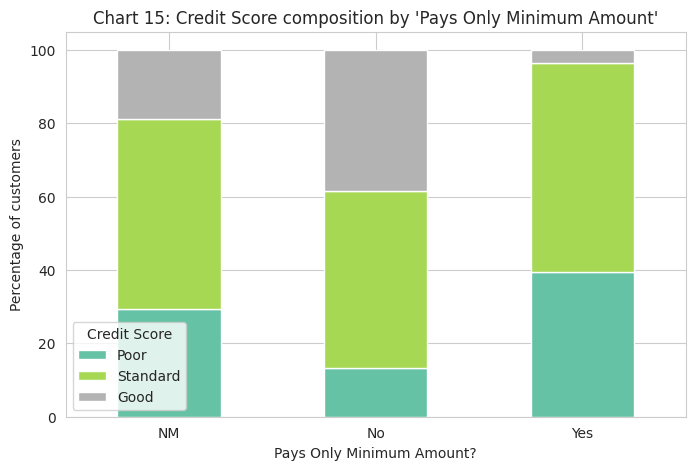

In [ ]:
# Chart - 15 visualization code
ct2 = pd.crosstab(data["Payment_of_Min_Amount"], data["Credit_Score"], normalize="index") * 100
ct2 = ct2[["Poor", "Standard", "Good"]]
ct2.plot(kind="bar", stacked=True, colormap="Set2", figsize=(8, 5))
plt.title("Chart 15: Credit Score composition by 'Pays Only Minimum Amount'")
plt.xlabel("Pays Only Minimum Amount?")
plt.ylabel("Percentage of customers")
plt.legend(title="Credit Score")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

Another 100% stacked bar, comparing whether paying only the minimum amount relates to the score.

##### 2. What is/are the insight(s) found from the chart?

Customers who pay **only the minimum ('Yes')** have a far higher share of **Poor** scores (~40%) than those who don't ('No', ~13%). Paying only the minimum is a warning sign.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this is a simple yes/no flag that separates risk well and is easy to act on. **Actionable advice:** encouraging customers to pay more than the minimum is a low-effort way to improve their score and reduce default risk.

#### Chart - 16

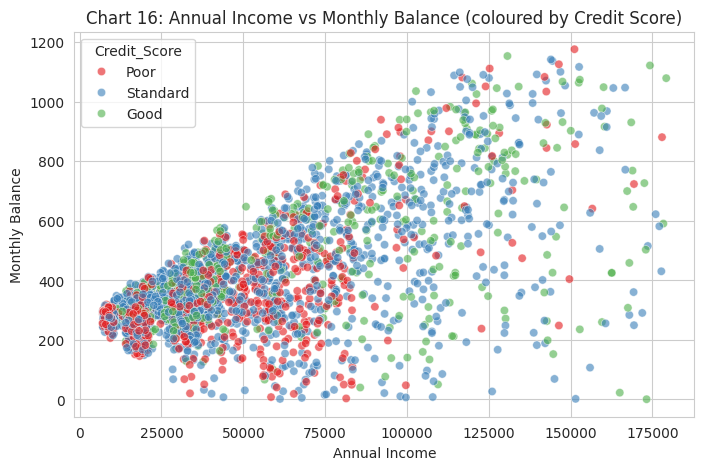

In [ ]:
# Chart - 16 visualization code
# Scatter plot = each dot is one customer, positioned by two numeric values.
# We sample 3,000 rows so the chart is not overcrowded.
sample = data.sample(3000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Annual_Income", y="Monthly_Balance", data=sample,
                hue="Credit_Score", hue_order=["Poor", "Standard", "Good"],
                palette="Set1", alpha=0.6)
plt.title("Chart 16: Annual Income vs Monthly Balance (coloured by Credit Score)")
plt.xlabel("Annual Income")
plt.ylabel("Monthly Balance")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot shows the relationship between two continuous variables, and colouring the dots by score adds a third dimension for free.

##### 2. What is/are the insight(s) found from the chart?

Higher income generally comes with a higher monthly balance, and **Good** customers (one colour) cluster toward higher income and balance, while **Poor** customers cluster low-left.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** confirms that healthy cash flow (income plus balance left over) travels with a good score, supporting the use of monthly balance as a supporting indicator in assessment.

#### Chart - 17

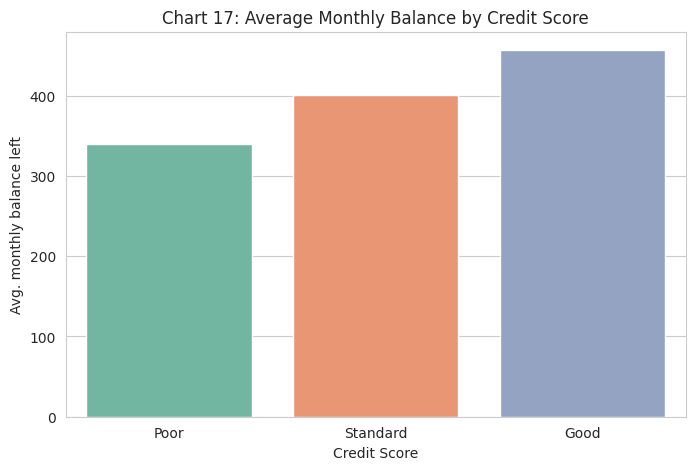

In [ ]:
# Chart - 17 visualization code
plt.figure(figsize=(8, 5))
sns.barplot(x="Credit_Score", y="Monthly_Balance", data=data,
            order=["Poor", "Standard", "Good"], palette="Set2", errorbar=None)
plt.title("Chart 17: Average Monthly Balance by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Avg. monthly balance left")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot of the average monthly balance summarises the scatter above into one clear comparison.

##### 2. What is/are the insight(s) found from the chart?

Average leftover monthly balance **rises with score**: ~339 (Poor), ~400 (Standard), ~457 (Good). Good customers keep more money after expenses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** monthly balance is a useful affordability check - customers with very little left each month are higher risk. Helps size loan offers responsibly.

### **Multivariate Analysis** (many variables at once)

#### Chart - 18 - Correlation Heatmap

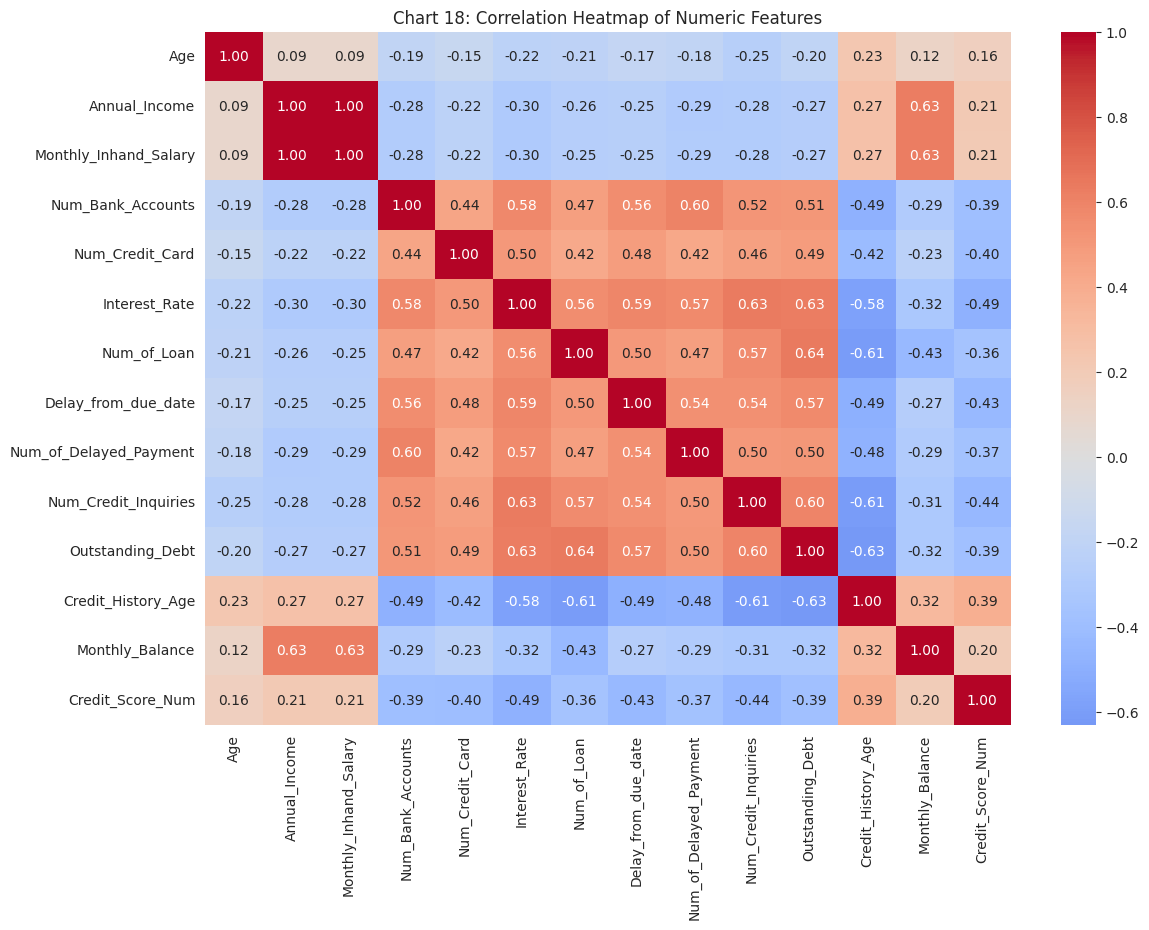

In [ ]:
# Correlation Heatmap visualization code
# Correlation measures how strongly two numeric columns move together:
#  +1 = move up together, -1 = one goes up as the other goes down, 0 = no link.
# A heatmap colours these correlations so strong links jump out.
num_cols = ["Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
            "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
            "Num_of_Delayed_Payment", "Num_Credit_Inquiries", "Outstanding_Debt",
            "Credit_History_Age", "Monthly_Balance", "Credit_Score_Num"]
plt.figure(figsize=(13, 9))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Chart 18: Correlation Heatmap of Numeric Features")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to see all pairwise numeric relationships in one picture, so we can quickly spot which features drive the score and which move together.

##### 2. What is/are the insight(s) found from the chart?

Looking at the `Credit_Score_Num` row: score is **negatively** correlated with Interest_Rate (-0.49), Num_Credit_Inquiries (-0.44), Delay_from_due_date (-0.43), Num_Credit_Card (-0.40) and Outstanding_Debt (-0.39), and **positively** correlated with Credit_History_Age (+0.39) and Annual_Income (+0.21). This matches every bivariate chart above and confirms the drivers are consistent.

#### Chart - 19 - Pair Plot

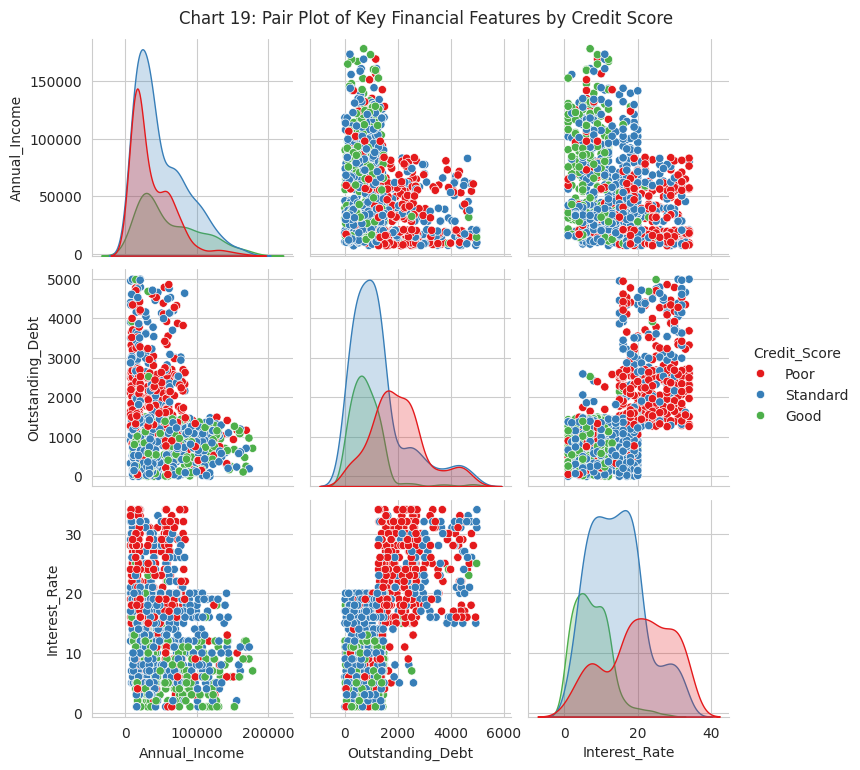

In [ ]:
# Pair Plot visualization code
# A pair plot draws a grid of scatter plots for several numeric columns at once,
# coloured by Credit Score. We use a small sample and few columns so it renders quickly.
pair_cols = ["Annual_Income", "Outstanding_Debt", "Interest_Rate", "Credit_Score"]
sns.pairplot(data.sample(1200, random_state=42)[pair_cols],
             hue="Credit_Score", hue_order=["Poor", "Standard", "Good"], palette="Set1")
plt.suptitle("Chart 19: Pair Plot of Key Financial Features by Credit Score", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot lets us view several two-way relationships simultaneously and see how the three score groups separate across all of them at once.

##### 2. What is/are the insight(s) found from the chart?

The score groups separate cleanly: **Good** customers cluster at low interest rate and low outstanding debt, while **Poor** customers cluster at high interest rate and high debt. Income overlaps more, confirming that repayment behaviour separates groups better than income alone.

#### Chart - 20 - Grouped Financial Profile

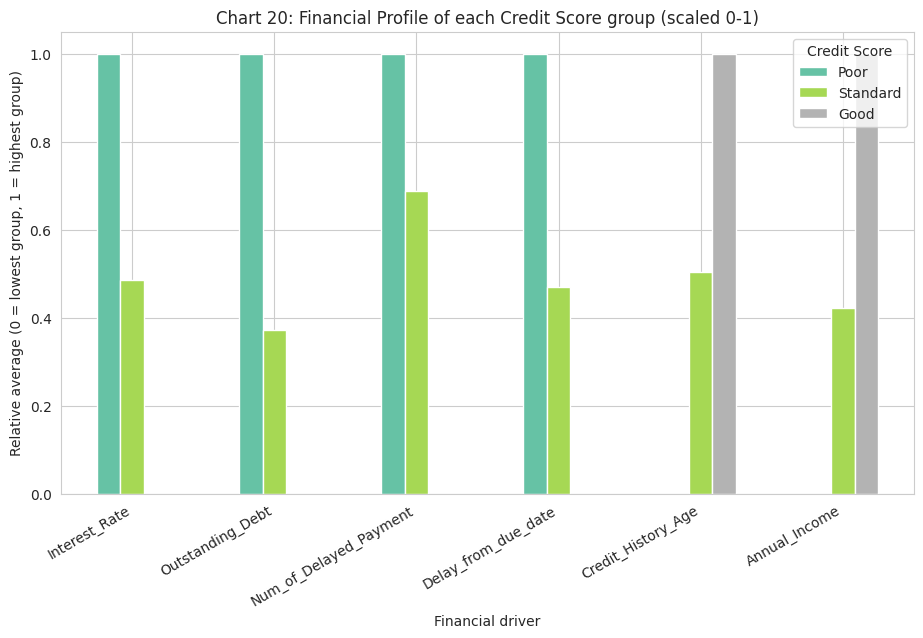

In [ ]:
# Chart - 20 visualization code
# A grouped bar chart comparing the average of several key drivers across score groups,
# after scaling each to a 0-1 range so they fit on one chart.
profile_cols = ["Interest_Rate", "Outstanding_Debt", "Num_of_Delayed_Payment",
                "Delay_from_due_date", "Credit_History_Age", "Annual_Income"]
means = data.groupby("Credit_Score")[profile_cols].mean()
scaled = (means - means.min()) / (means.max() - means.min())   # scale each column 0-1
scaled = scaled.loc[["Poor", "Standard", "Good"]]
scaled.T.plot(kind="bar", figsize=(11, 6), colormap="Set2")
plt.title("Chart 20: Financial Profile of each Credit Score group (scaled 0-1)")
plt.xlabel("Financial driver")
plt.ylabel("Relative average (0 = lowest group, 1 = highest group)")
plt.legend(title="Credit Score")
plt.xticks(rotation=30, ha="right")
plt.show()

##### 1. Why did you pick the specific chart?

A single grouped bar chart that puts all the main drivers side by side gives one clear 'fingerprint' of each credit-score group - a strong storytelling summary chart.

##### 2. What is/are the insight(s) found from the chart?

The fingerprints are opposite: **Poor** customers score high on the 'bad' drivers (interest rate, debt, delayed payments, delay days) and low on the 'good' ones (credit history, income). **Good** customers are the reverse. Standard sits in between on almost everything.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive impact:** this one chart summarises the entire analysis for stakeholders and directly names the five-or-six variables Paisabazaar should build its credit-risk rules and future model around.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, I suggest Paisabazaar focus on a **small set of high-signal variables** rather than judging every column equally. The strongest, most consistent drivers of a customer's credit score are: **Interest Rate, Outstanding Debt, Payment Delays (both the number of delayed payments and how many days late), Credit Mix, Credit History length, and whether the customer pays only the minimum amount.**

Concretely:

1. **Build a risk-screening checklist / scorecard** around those six drivers so applications can be triaged quickly and consistently. A customer with high interest, high debt, many delayed payments and a 'Bad' credit mix is very likely 'Poor' and should be reviewed carefully.

2. **Create early-warning triggers.** Rising payment delays and paying only the minimum appear *before* a score collapses, so automated reminders or restructuring offers at that point protect both the customer and the loan book.

3. **Turn the insights into customer advice** - reduce outstanding debt, avoid opening many accounts/cards, pay more than the minimum, and keep payments on time. These are exactly the levers that separate Good from Poor customers.

4. **Extend this EDA into a predictive model.** The clean signals and correlations found here mean a classification model (e.g. Logistic Regression, Random Forest) could reliably predict a customer's credit-score bucket, automating the assessment - while accounting for the class imbalance seen in Chart 1.

# **Conclusion**

This project explored 100,000 customer credit records for Paisabazaar to understand what separates customers with **Good, Standard, and Poor** credit scores. The data was clean (no missing values or duplicates), so effort went into understanding the variables, sensibly handling outliers and skew, and building 20 charts in a Univariate -> Bivariate -> Multivariate order.

The findings tell one clear and consistent story: **a good credit score is driven far more by responsible repayment behaviour than by income alone.** Customers with Good scores pay much lower interest (~8% vs ~20% for Poor), carry roughly one-third of the outstanding debt, delay payments far less often, hold fewer bank accounts and credit cards, keep a 'Good' credit mix, and have a longer credit history. The correlation heatmap and pair plot confirmed these same drivers all point the same way.

**Most important insight:** payment behaviour and debt load (interest rate, outstanding debt, delayed payments, credit mix) are the sharpest dividing lines between Good and Poor customers - sharper than income.

For Paisabazaar this means faster, more consistent, and safer lending decisions, plus clear advice it can give customers to improve their scores. **Future improvements** include converting this analysis into a predictive machine-learning classifier, adding customer-level (not just monthly) aggregation, and building an interactive dashboard so risk teams can explore these drivers live.